# Replication of reskilling analysis from MSc thesis
Felix Zaussinger | 15.09.2022

**Core Analysis Goal(s)**
1. Replicate thesis approach based on updated data
2. Decide how to deal with skewed distribution when working with COOC matrix compared to ESCO matrix tables or Kanders Matrix
3. Understand and write down all of the assumptions that I make and reflect whether they are robust enough

**Key Insight(s)**
1. Replication based on ESCO v.1.1 is working!
2.
3.

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from tqdm import tqdm
from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

# load paths
from src import utils
from src.data.lfs import EuLfs
from src.modelling.reskilling import ReskillingPathways
from src.data.framework import Esco

useful_paths = utils.UsefulPaths()

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pd.options.display.float_format = "{:,.2f}".format

sns.set_context("paper", font_scale=1.5, rc={"figure.dpi": 72})
sns.set_style("ticks")

#### Load data

##### Auxillary data

In [2]:
earnings_deciles = pd.read_csv(
    os.path.join(
        useful_paths.data_raw, "metadata", "earnings_per_deciles.csv"
    ),
)

# Read geodata with NUTS regions
gdf = gpd.read_file(
    os.path.join(
        useful_paths.data_raw,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)

In [3]:
earnings_deciles

,country,decile,annual_earnings,year
0,DE,1,7635,2016
1,DE,2,11970,2016
2,DE,3,14817,2016
3,DE,4,17256,2016
4,DE,5,19692,2016
5,DE,6,22243,2016
6,DE,7,25088,2016
7,DE,8,28832,2016
8,DE,9,34299,2016
9,DE,10,55368,2016


##### LFS data

In [142]:
# esco data
esco = Esco()

# EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
lfs = EuLfs(config=config)
year = 2019

lfs_data = lfs.read_preprocessed_file(
    year=year, input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares_and_earnings_incdecil_imputed"
)

#### Initialise reskilling simulation

In [143]:
# reskilling simulations
osm_version = "weighted"
sim_metric = "cooc"
diagonal_zeros = False

rp = ReskillingPathways(osm_version=osm_version, sim_metric=sim_metric, lfs_data=lfs_data, year=year)

In [66]:
df_occs = rp.get_occs()

#### Computing occupation similarity at ISCO-3D level

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [11]:
# read occ sim matrix
df_occ_sims = rp.sim_matrix_at_level(level="isco_3_digit")

# create numpy matrix and fill diagonal with zeros (avoid self-transitions)
similarity_matrix = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix, 0)

#### Calibrate transition thresholds

##### Calculate within-group occupation similarities for different granularity levels

In [12]:
df_occ_sim = rp.df_occ_sim
df_sim_container = rp.calc_sim_means_by_level()

##### Plot results

In [144]:
rp.transition_thresholds = rp.calc_transition_thresholds(show_plots=False)
rp.transition_thresholds

,mean,sd,mean-sd,mean+sd,threshold_category
esco_5_digit,22.35,11.55,10.80,33.90,viable_high
isco_4_digit,14.47,10.79,3.68,25.26,viable
isco_3_digit,9.06,8.06,1.00,17.12,viable_low


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

##### Percentiles of overall distribution
1.616368047779022 6.500853535353546

In [68]:
q_viable, q_highly_viable = rp.trans_thresh_pc_approach
print(q_viable, q_highly_viable)

2.25 7.5


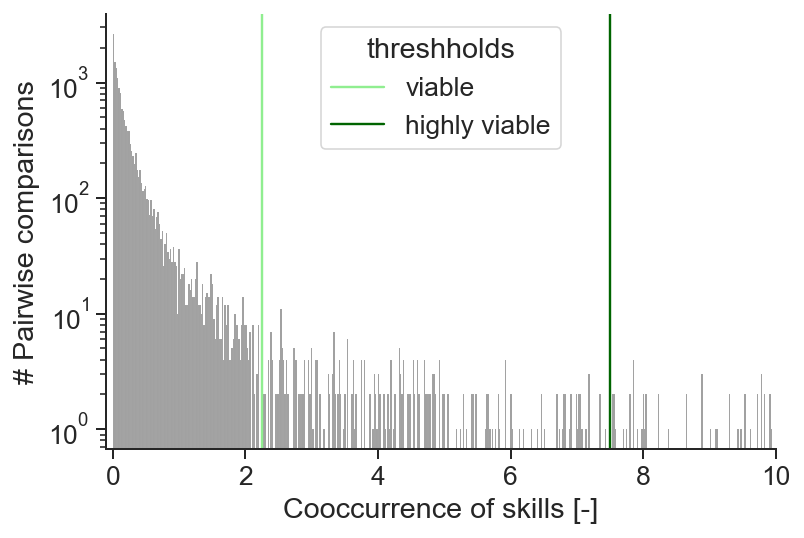

In [15]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey", log_scale=(False, True))
ax.set_xlim(-0.1, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

##### Plot occ sim matrix at ISCO 3 digit level

<AxesSubplot:xlabel='Target occupations (isco_3_digit)', ylabel='Source occupations (isco_3_digit)'>

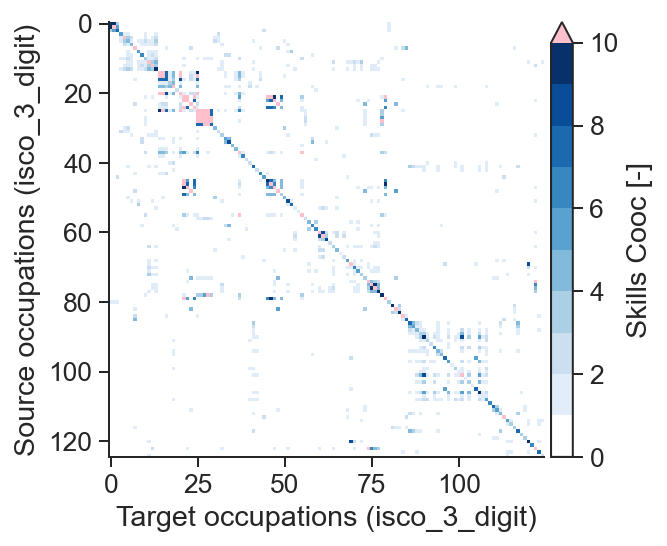

In [69]:
rp.plot_sim_matrix_at_level(vmax=10, mask_upper=False)

##### Plot occupation similarity matrix classified viable/highly viable

<AxesSubplot:xlabel='Target occupations (isco_4_digit)', ylabel='Source occupations (isco_4_digit)'>

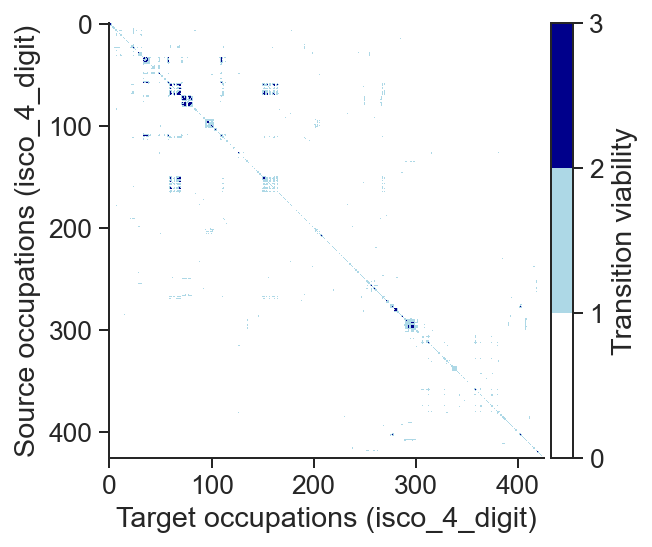

In [17]:
rp.plot_sim_matrix_at_level(level="isco_4_digit", classify=True, mask_upper=False)

#### Transition analysis logic
Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

#### Manually check some transitions

In [78]:
rp.coal_occupations

{'Mining, manufacturing and construction supervisors': '312',
 'Mining and mineral processing plant operators': '811',
 'Manufacturing, mining, construction, and distribution managers': '132',
 'Mining and construction labourers': '931'}

In [91]:

occ = df_occs.loc[df_occs.preferredLabel == "Mining and mineral processing plant operators"]
print(occ.preferredLabel)

transitions = find_closest(
    i=occ.index.values[0], similarity_matrix=similarity_matrix, df=df_occs
)

transitions.head(5)


100    Mining and mineral processing plant operators
Name: preferredLabel, dtype: object


,conceptUri,preferredLabel,code,similarity
90,http://data.europa.eu/esco/isco/C722,"Blacksmiths, toolmakers and related trades wor...",722,1.78
101,http://data.europa.eu/esco/isco/C812,Metal processing and finishing plant operators,812,1.72
106,http://data.europa.eu/esco/isco/C817,Wood processing and papermaking plant operators,817,1.58
103,http://data.europa.eu/esco/isco/C814,"Rubber, plastic and paper products machine ope...",814,1.41
89,http://data.europa.eu/esco/isco/C721,"Sheet and structural metal workers, moulders a...",721,1.08


### Analyse number of viable transitions

#### Parameters

In [145]:
rp.trans_thresh_pc_approach = 1.616368047779022, 6.500853535353546
#rp.trans_thresh_pc_approach = 1.5, 6

In [101]:
from src import plotting_utils

# colorbars
cmap_earnings = plt.get_cmap("coolwarm_r", 8)
cmap_earnings.set_over("darkblue")
cmap_earnings.set_under("darkred")

#cmap_transitions = plotting_utils.discrete_cmap_with_manual_colors(cmap_type="Blues", n_classes=5)
cmap_transitions = plt.get_cmap("Blues", 10)
cmap_transitions.set_over("darkblue")

# upper limits for colorbars
vmax_transitions = 10  # n viable transitions
vmax_wages = 40  # million euro

# initialise dict to store estimates of total wage changes
earnings_losses = {}

# choice of source transition pool
transition_pool = "coal"
#df_transition_pool = transition_pool_options[transition_pool]

# choice of weights for transition pool of search occupation: COEFF > COEFF_share_brown_sl > COEFF_share_brown_slt
transition_pool_weights = "COEFF"

# remedy from  thesis
run_skills_continuity_scenarios = False

# create results dir
out_dirname = "{}_occupations_by_{}".format(
    transition_pool, transition_pool_weights.lower()
)
out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation", out_dirname)
utils.ccdir(out_dir)

#### Scenario 1: Workers follow closest viable transition regardless of earnings losses (Skills continuity scenario)

In [146]:
%%time
baseline_simulations = rp.simulate_baseline(level="isco_3_digit", countries=["DE"], scenarios=["coal"], transition_optimisation="skill")

1.616368047779022 6.500853535353546
scenario: coal
  country: DE
    transition pool: 35190.17 workers (n=232)


232it [00:01, 203.27it/s]

CPU times: total: 1.72 s
Wall time: 1.78 s


#### Scenario 2a) Wage continuity

In [147]:
%%time
baseline_simulations = rp.simulate_baseline(level="isco_3_digit", countries=["DE"], scenarios=["coal"], transition_optimisation="wage")

1.616368047779022 6.500853535353546
scenario: coal
  country: DE
    transition pool: 35190.17 workers (n=232)


232it [00:01, 210.30it/s]

CPU times: total: 1.44 s
Wall time: 1.53 s


coal
DE


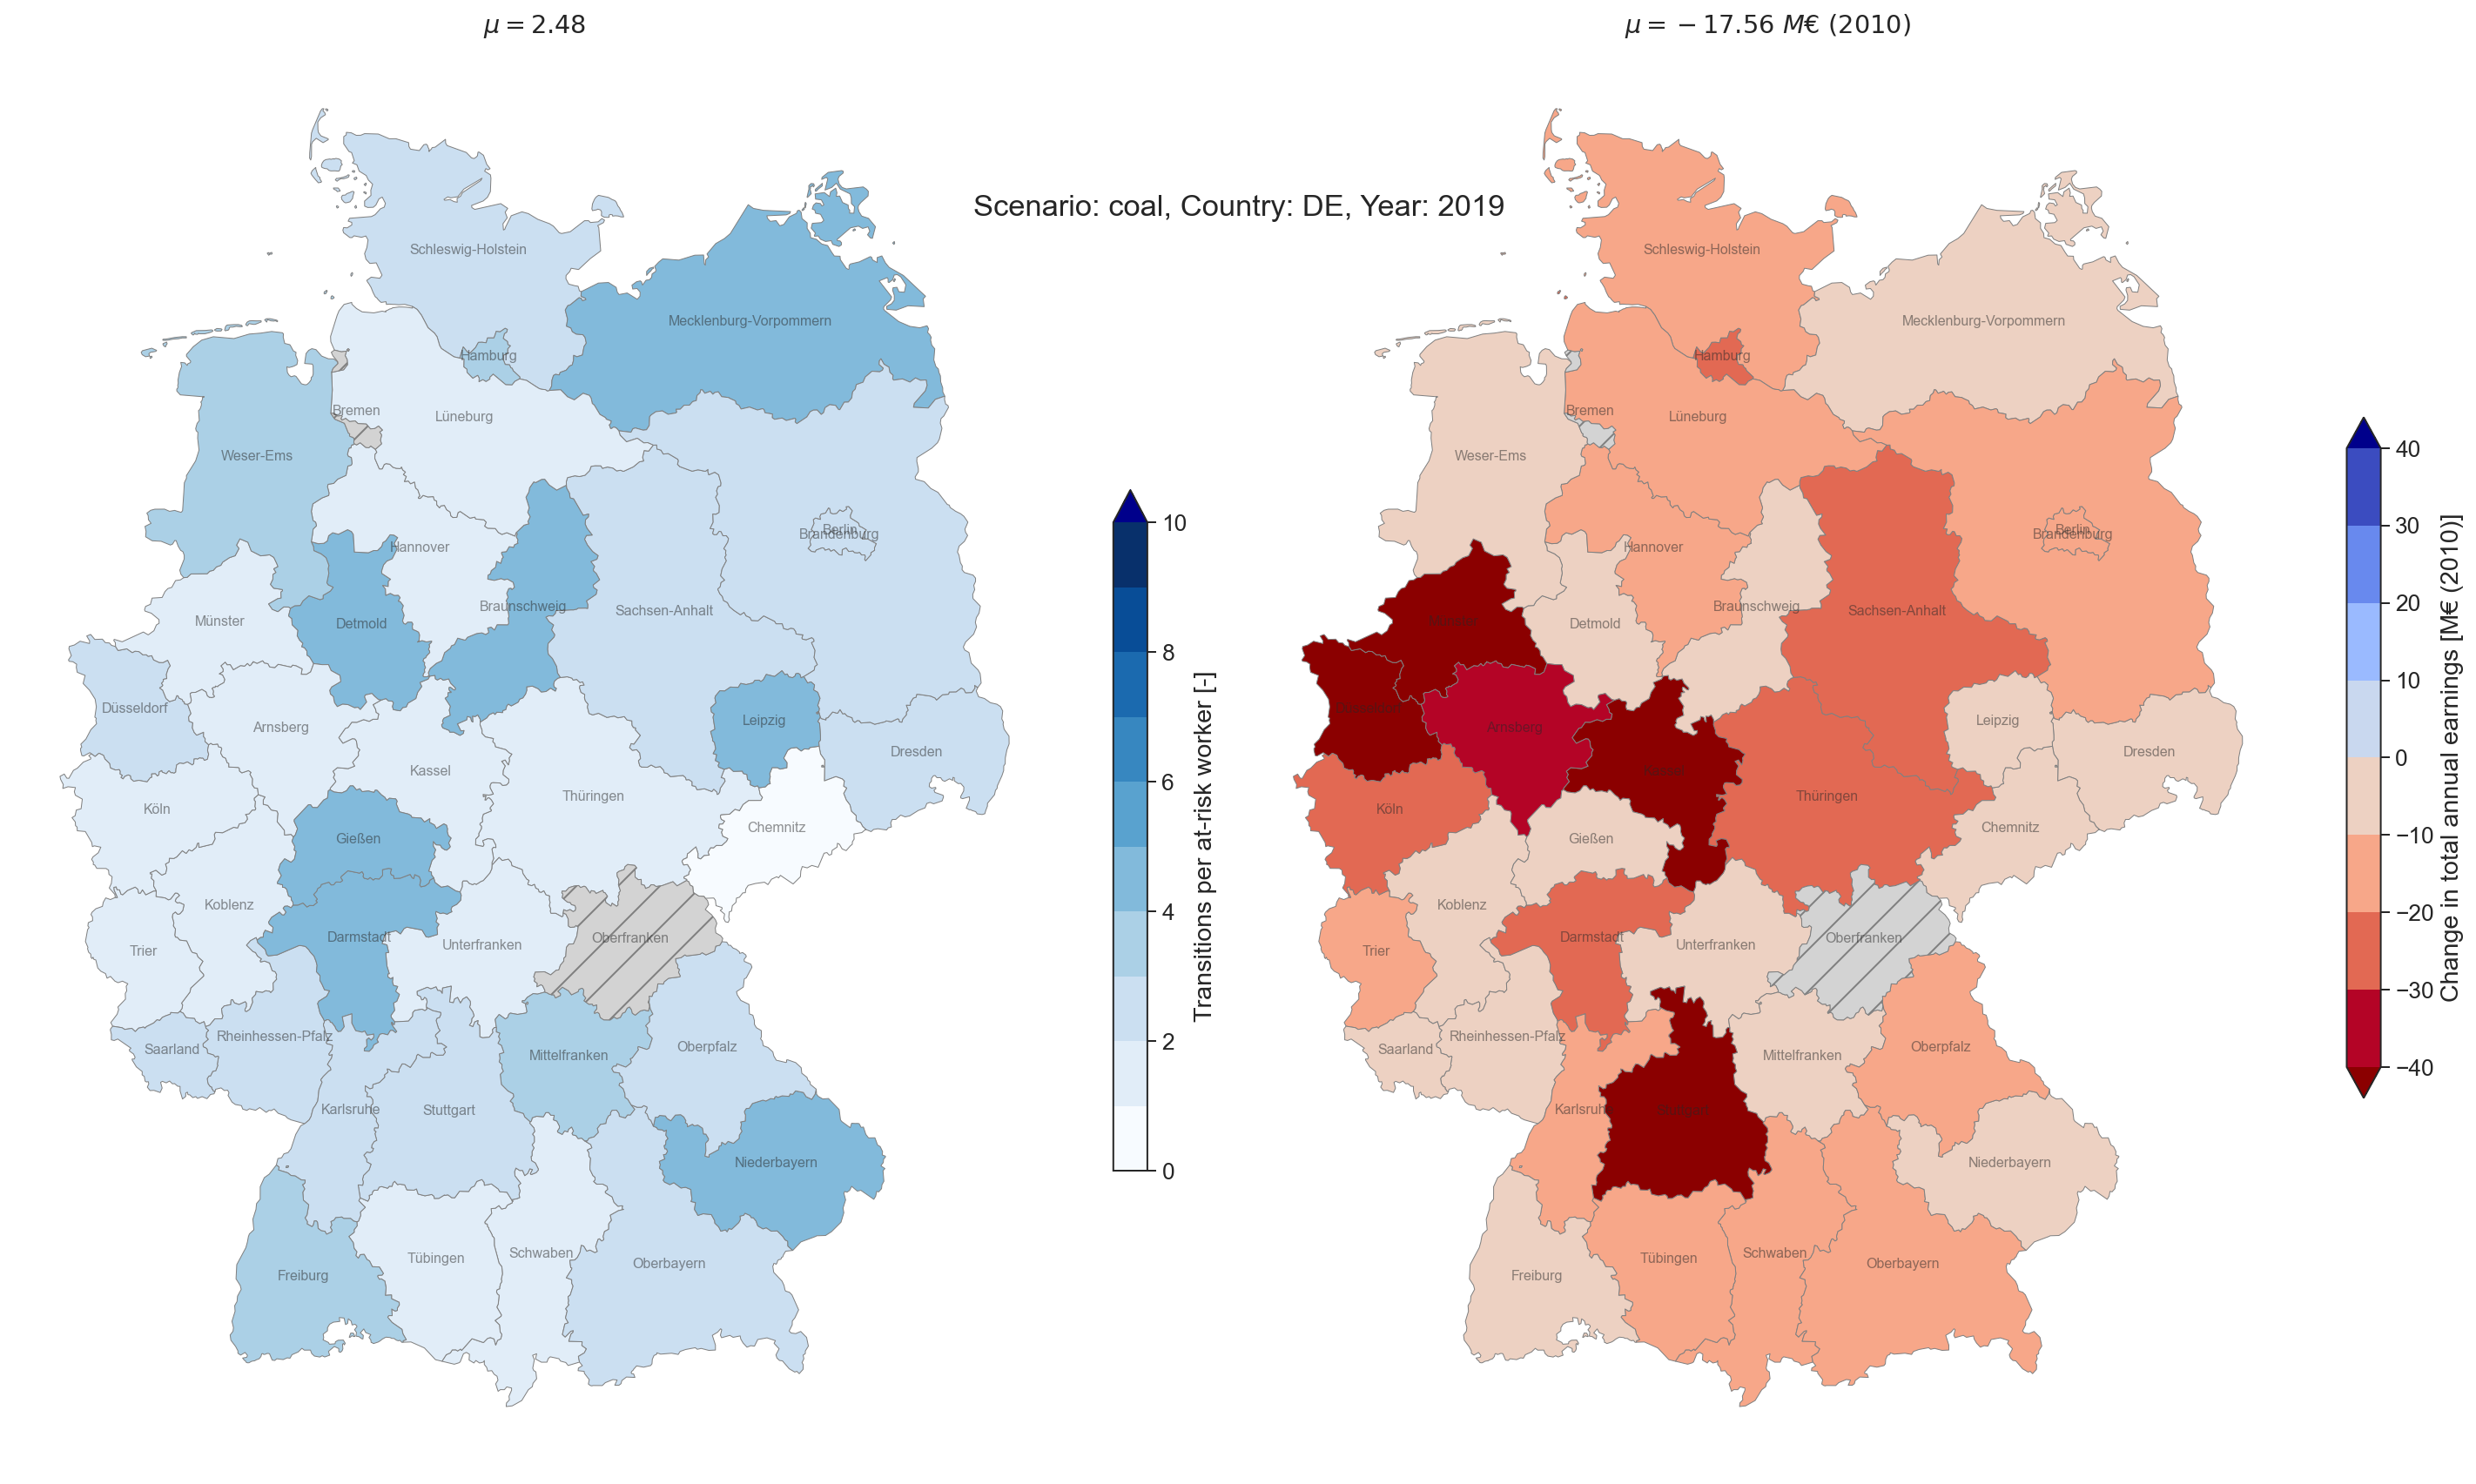

In [166]:
rp.visualise_simulation_results(simulation_results=baseline_simulations)

To geodataframe

##### Regional distribution of transition pathways

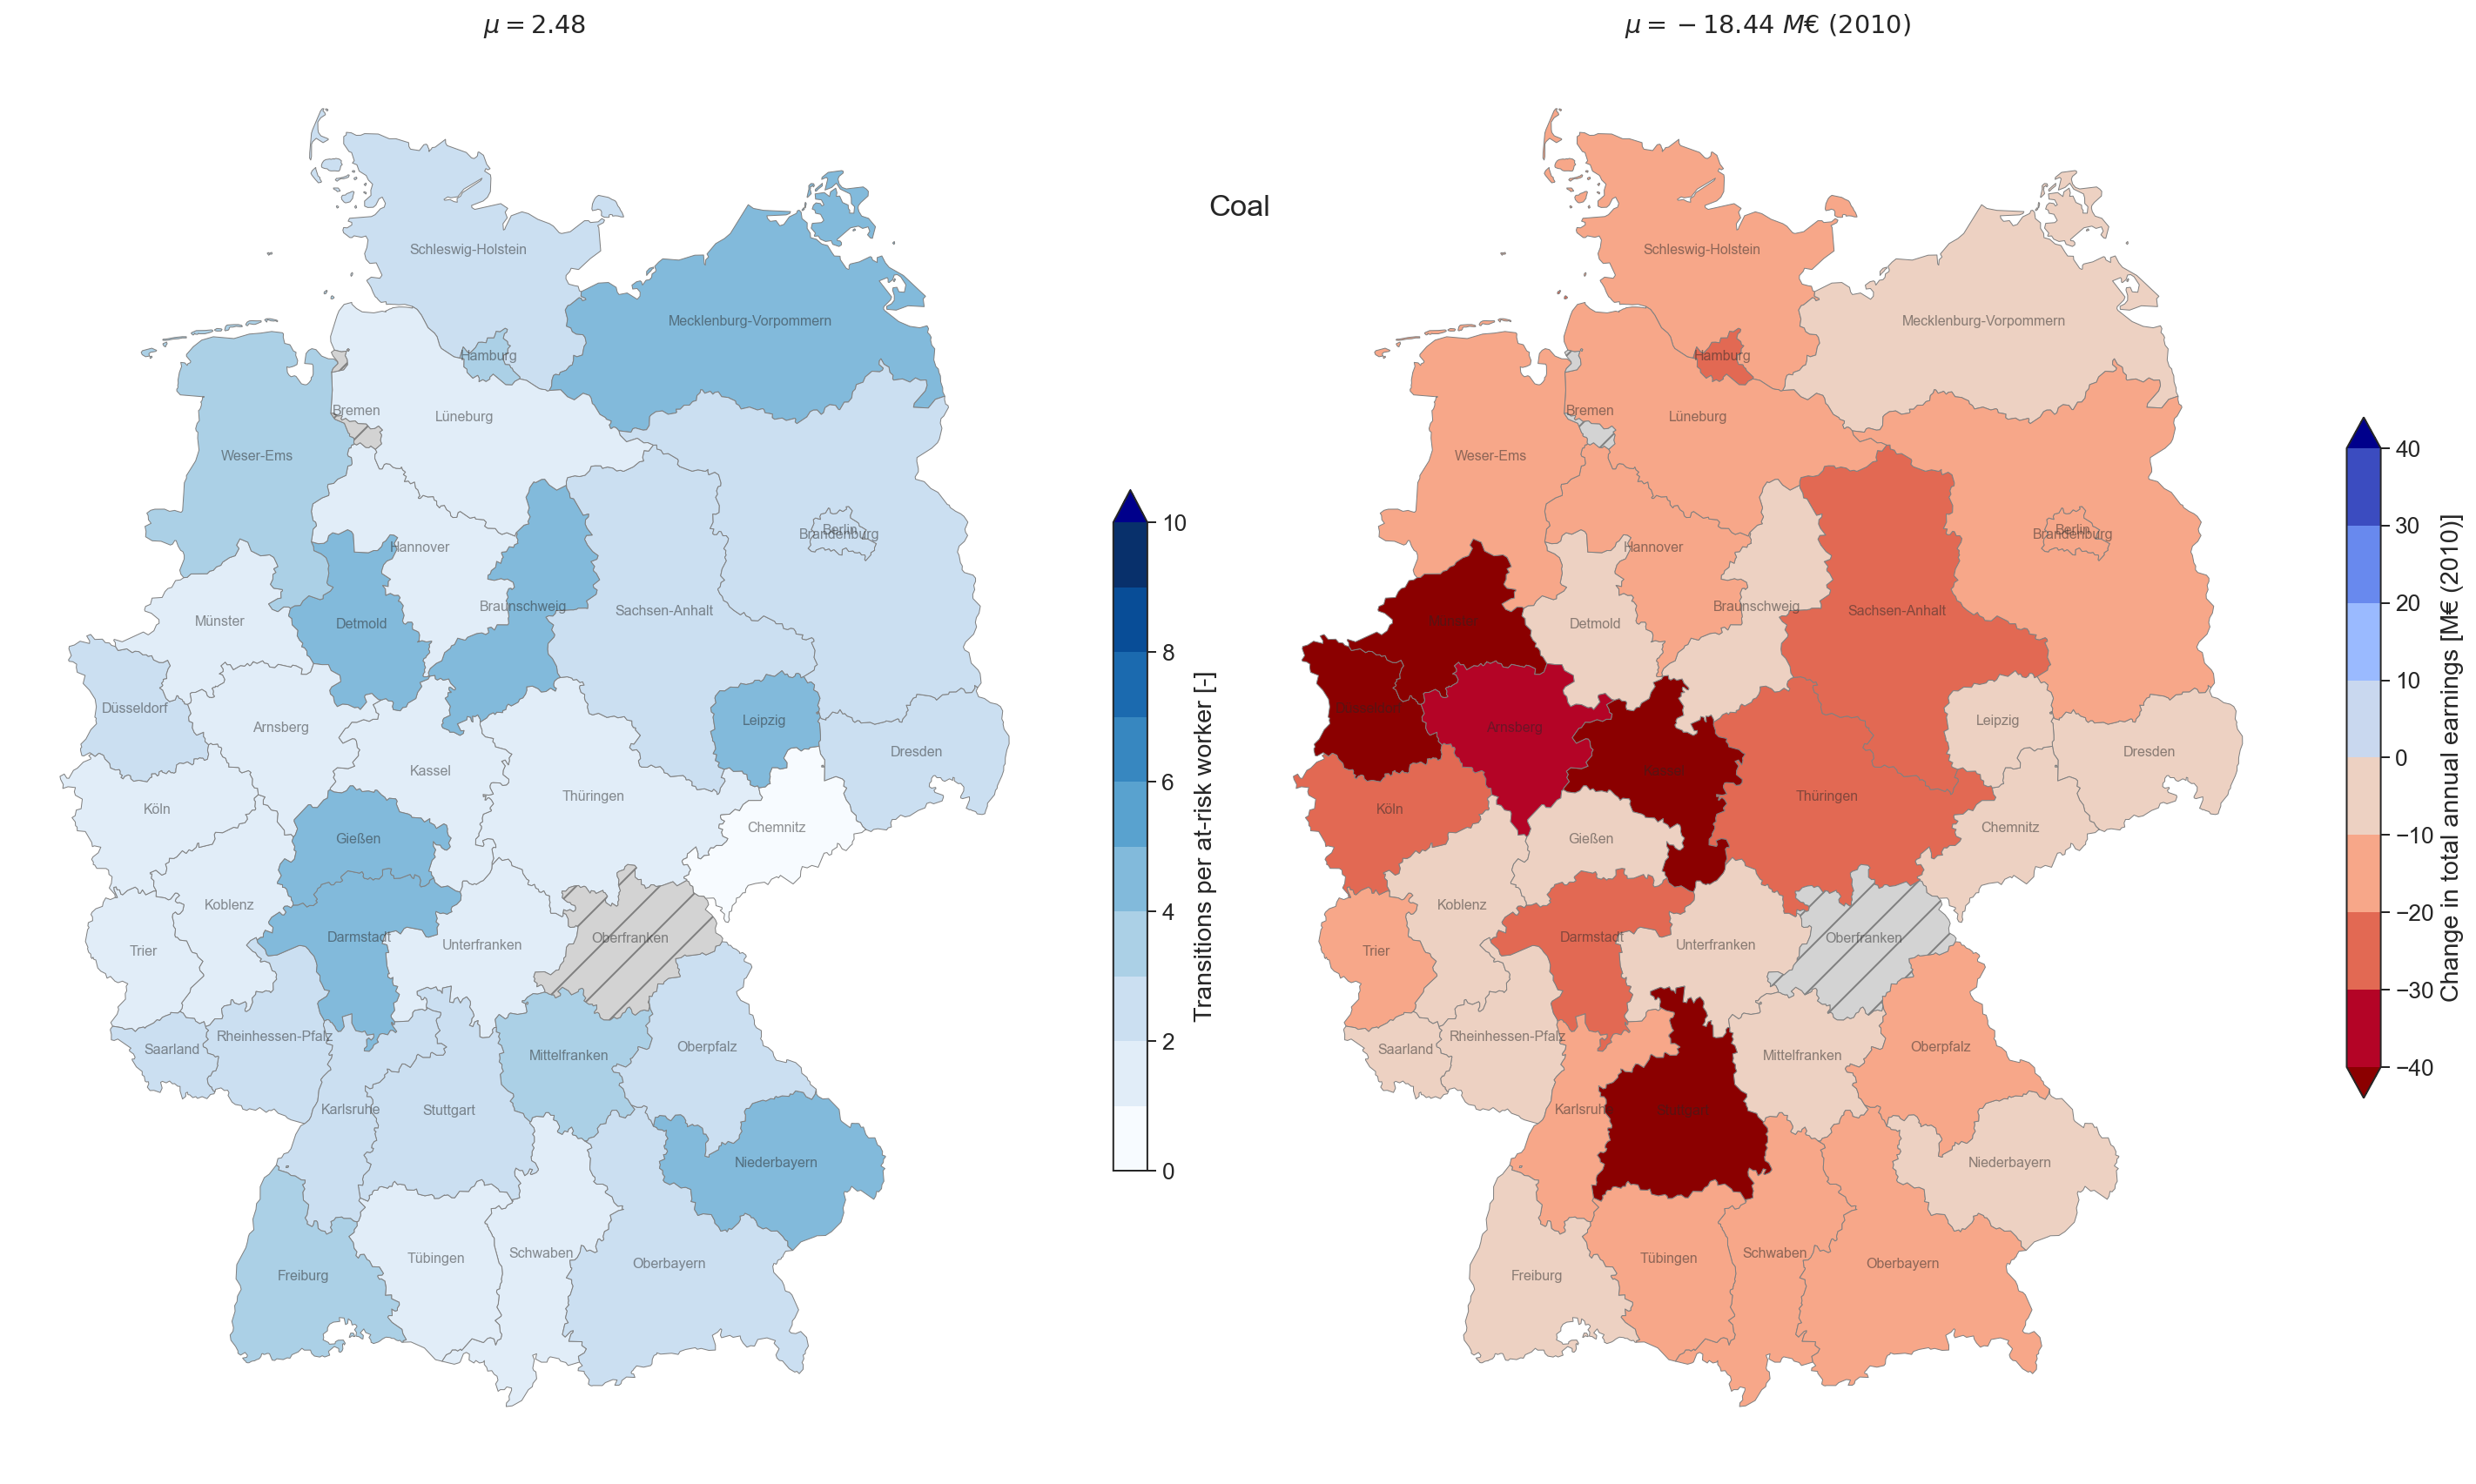

In [164]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 20))

# transition numbers
gdf_transition_numbers_by_nuts.plot(
    column="n_viable_transitions_rel",
    legend=True,
    cmap=cmap_transitions,
    vmin=0,
    vmax=vmax_transitions,
    legend_kwds={
        "label": "Transitions per at-risk worker [-]",
        "fraction": 0.03,
        "extend": "max",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
    ax=ax1
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax1.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)


ax1.set_title(
    "$\mu = {:.2f}$".format(
        gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()
    )
)
ax1.axis("off")

# earnings losses
v = vmax_wages
gdf_transition_numbers_by_nuts.plot(
    column="earnings_delta_closest_switch_sum_mio",
    legend=True,
    cmap=cmap_earnings,
    vmin=-v,
    vmax=v,
    legend_kwds={
        "label": "Change in total annual earnings [M€ (2010)]",
        "fraction": 0.03,
        "extend": "both",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
    ax=ax2
)

gdf_transition_numbers_by_nuts.apply(
    lambda x: ax2.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax2.set_title(
    "$\mu = {:.2f}~M€~(2010)$".format(
        gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum_mio.mean()
    )
)
ax2.axis("off")

# layout
fig.suptitle("Coal")
fig.tight_layout()
fig.subplots_adjust(top=1.5)

plt.savefig(
    os.path.join(
        useful_paths.figure_dir, "reskilling_simulation", "n_transitions_by_region.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

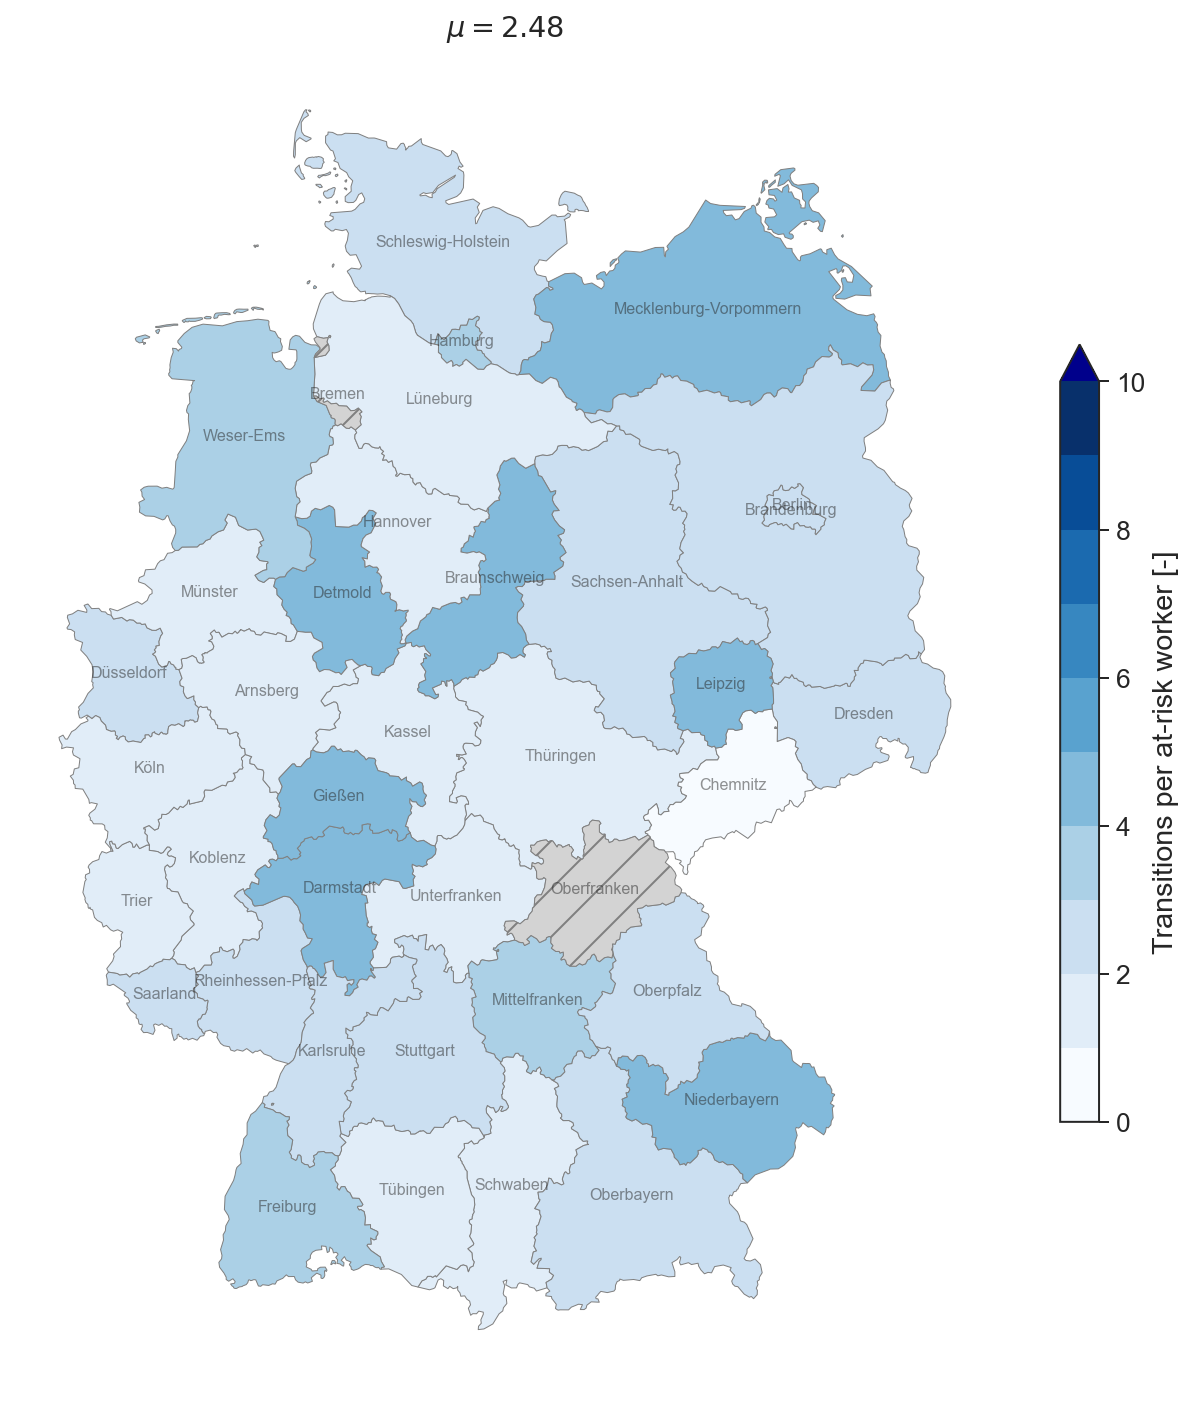

In [136]:
ax = gdf_transition_numbers_by_nuts.plot(
    column="n_viable_transitions_rel",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_transitions,
    vmin=0,
    vmax=vmax_transitions,
    legend_kwds={
        "label": "Transitions per at-risk worker [-]",
        "fraction": 0.03,
        "extend": "max",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)


ax.set_title(
    "$\mu = {:.2f}$".format(
        gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir, out_dir, "n_transitions_by_region.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Regional distribution of earnings changes

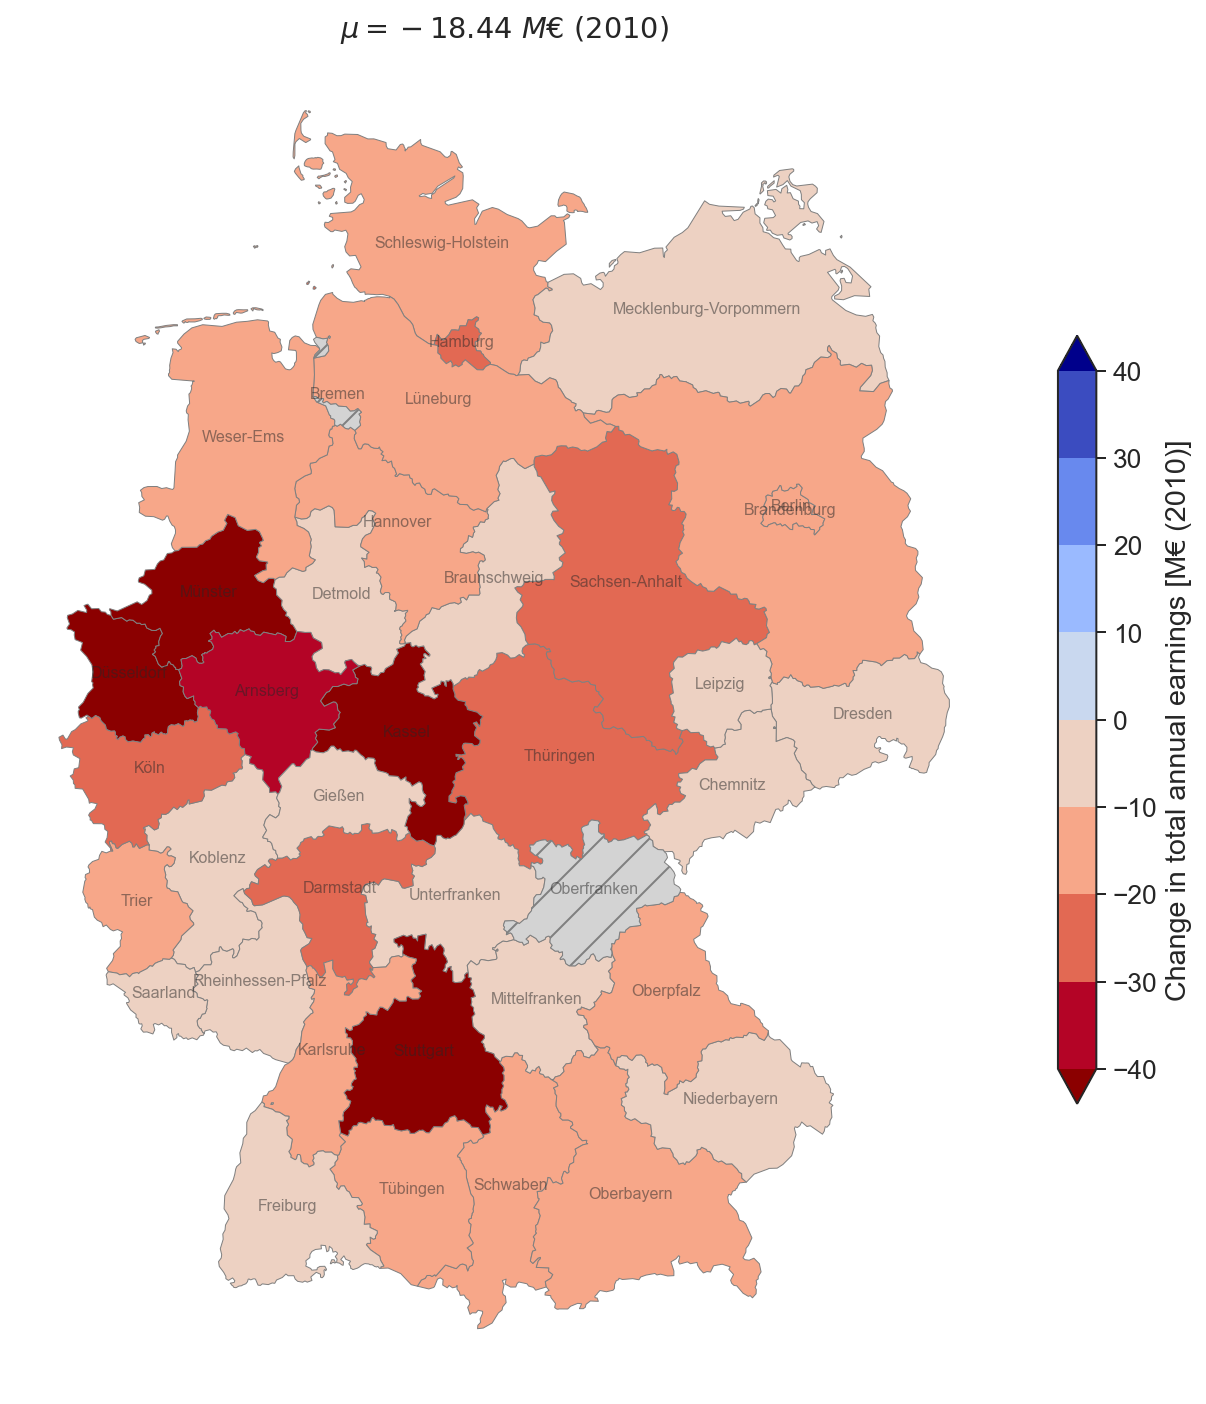

In [137]:
v = vmax_wages
ax = gdf_transition_numbers_by_nuts.plot(
    column="earnings_delta_closest_switch_sum_mio",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_earnings,
    vmin=-v,
    vmax=v,
    legend_kwds={
        "label": "Change in total annual earnings [M€ (2010)]",
        "fraction": 0.03,
        "extend": "both",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax.set_title(
    "$\mu = {:.2f}~M€~(2010)$".format(
        gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum_mio.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_region.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (mean/median)

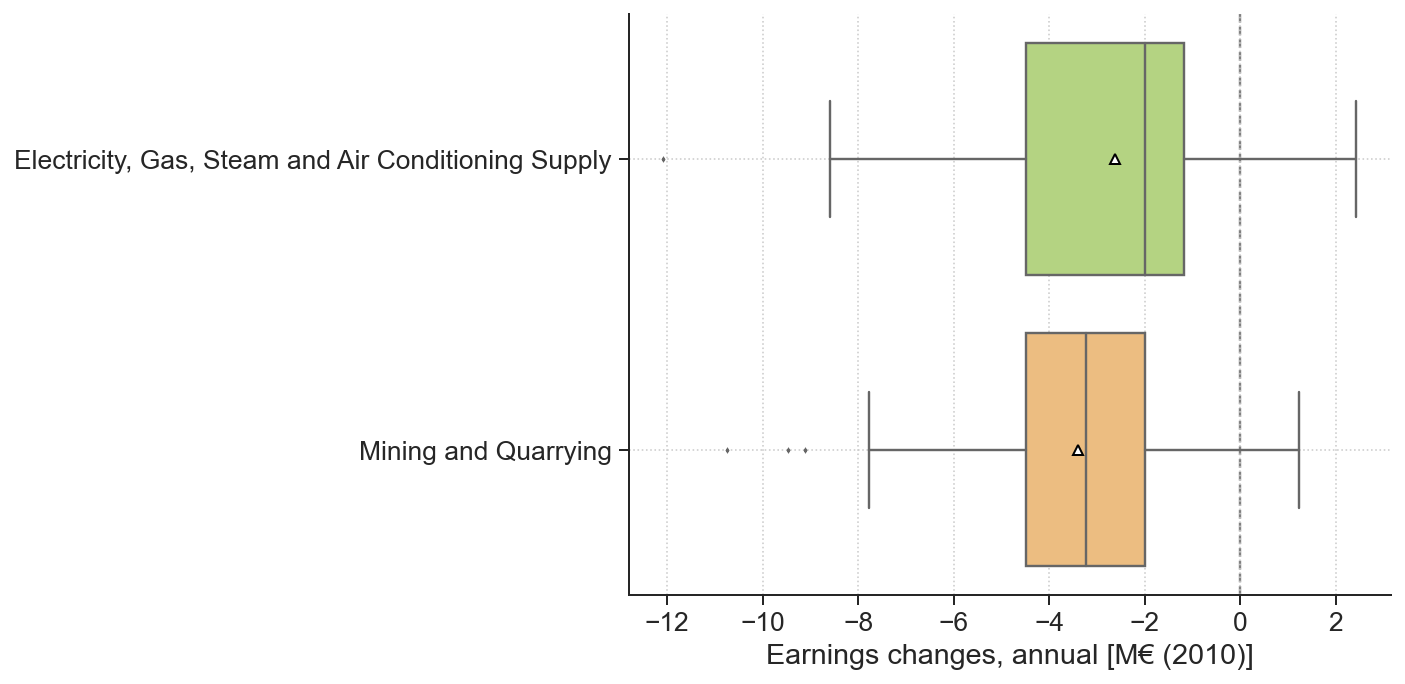

In [138]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers.groupby("NACE1D_label").median()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.boxplot(
    data=df_transition_numbers,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    fliersize=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "5",
    },
    order=y_order,
    palette="RdYlGn_r"
)

# sns.stripplot(
#     data=df_transition_numbers,
#     x="earnings_delta_closest_switch_sum_mio",
#     y="NACE1D_label",
#     orient="h",
#     alpha=.5,
#     edgecolor="gray",
#     linewidth=1,
#     zorder=1
# )

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (sum)

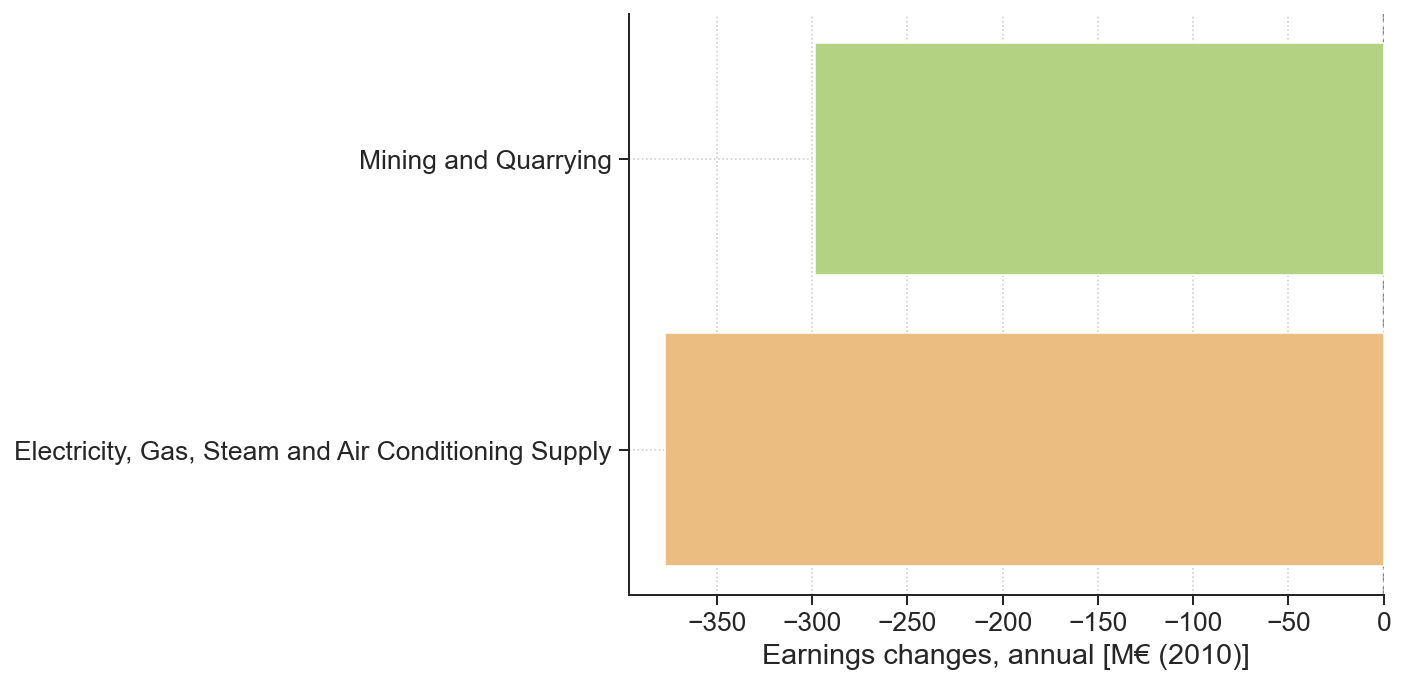

In [139]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers.groupby("NACE1D_label").sum()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.barplot(
    data=df_transition_numbers,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    estimator=np.sum,
    ci=None,
    order=y_order,
    palette="RdYlGn_r"
)

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_sum.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Comparison of costs with Kohleaustiegsbudget

In [ ]:
earnings_losses[
    "wage_continuity"
] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(
    np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
    / (40 * 10**9)
)
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

#### Scenario 2b) Wage continuity + regional constraint

##### Compute transitions

In [ ]:
# unique regions
nuts_codes = df_de.NUTS_ID.dropna().unique()

# job availability by region
regional_job_availability = occ_number_by_nuts2_and_isco3.reset_index()

# fraction of total current jobs in (neutral or green) target occupation B that could be added to employ workers transitioning from (brown) source occupation A
max_fraction_in_target_occ = 0.1

In [ ]:
%%time

results_by_region = {}
# outer loop: regions
for nuts_code in tqdm(nuts_codes):
    print(nuts_code)

    # absolute n of jobs in region per occupation category
    regional_job_availability_subset = regional_job_availability[regional_job_availability.NUTS_ID == nuts_code]

    # inner loop: at-risk jobs grouped by source occupation category
    transition_number_data = []

    # subset transition pool
    regional_transition_pool = df_transition_pool.loc[df_transition_pool["NUTS_ID"] == nuts_code]
    regional_occs = regional_transition_pool.ISCO3D_label.unique()
    print("number of at-risk jobs:", regional_transition_pool.COEFF.sum())

    for i, search_occ_label in enumerate(regional_occs):
        print(occ)
        # pool of transitioning workers in region i and occupation j
        transitions_by_occ = regional_transition_pool[regional_transition_pool.ISCO3D_label == search_occ_label]

        # absolute number of transitioning workers in region i and occupation j
        n_workers_transitioning = transitions_by_occ[transition_pool_weights].sum()

        # find index of search occ and closest target occs
        idx = df_occs.loc[df_occs.occ == search_occ_label].index.values[0]
        target_occs = find_closest(
            i=idx, similarity_matrix=similarity_matrix, df=df_occs_metadata
        )

        # filter criteria 1: sim > viability threshold
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]

        # filter criteria 2: target occupation is neutral or green
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # combine with job availability at regional level
        target_occs_filtered = target_occs_filtered.merge(regional_job_availability_subset, left_on="occ", right_on="ISCO3D_label", how="left", suffixes=("", "_target_regional"))

        # fraction of transitioning workers of existing workers in region i and occupation j
        target_occs_filtered["fraction_of_transitioning_workers"] =  n_workers_transitioning / target_occs_filtered["COEFF_target_regional"]

        # filter criteria 3: workers choose target occupation that minimises their earnings losses
        target_occs_filtered["wage_diff"] = (
            target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
        )

        # (optional) filter criteria 3, regional: drop target occupations that can likely not absorb the transitioning workers
        target_occs_filtered = target_occs_filtered[target_occs_filtered["fraction_of_transitioning_workers"] <= max_fraction_in_target_occ]

        print(transitions_by_occ)
        print(target_occs_filtered)

        assert 1 == 2

        # if I know the wage of the source occupation, choose transition that minimises wage losses
        if search_obs.annual_earnings_2016 != np.nan:
            target = target_occs_filtered.sort_values("wage_diff").tail(1)
        else:
            # if not, choose transition with highest target wage
            target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            search_obs["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            )
            search_obs["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            ) * search_obs[transition_pool_weights]
            search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
            search_obs["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
            )
            search_obs["transition_viable"] = True
            search_obs["transition_target"] = target.occ.values[0]
            search_obs["target_category"] = target.category.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            search_obs[
                "earnings_delta_closest_switch"
            ] = search_obs.annual_earnings_2016 * (-1)
            search_obs["earnings_delta_closest_switch_sum"] = (
                search_obs.annual_earnings_2016 * (-1) * search_obs[transition_pool_weights]
            )
            search_obs["n_viable_transitions"] = 0
            search_obs["n_viable_transitions_sum"] = 0
            search_obs["transition_viable"] = False
            search_obs["transition_target"] = None
            search_obs["target_category"] = None

        transition_number_data.append(search_obs)
    results_by_region[nuts_code] = transition_number_data

    # delete after
    break

results_by_region

In [ ]:
transitions_by_occ
search_obs

In [ ]:
regional_transition_pool[regional_transition_pool.ISCO3D_label == search_obs.ISCO3D_label].sum()

## Upskilling analysis
- use stylised results from the upskilling analyis
- add skills that were found to unlock the most additional viable transitions per occupation to profile before calculating transitions
- pre-compute 4 different similarity matrices where those skills are already added

In [ ]:
df_top_skills_per_occ_all = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_best_5_skills_per_isco3d_occupation.csv",
    ),
    index_col=0,
)

# subset brown occupations
df_top_skills_per_occ = df_top_skills_per_occ_all[
    df_top_skills_per_occ_all.Occupation.isin(list(transition_pool_dict.keys()))
]

if two skills unlock the same (top) number of new viable transitions, choose the one with the higher coreness

In [ ]:
isco_group_dict = dict(zip(isco_groups_labels.preferredLabel, isco_groups_labels.code))

In [ ]:
optimal_upskilling_per_occ = []
for group, df in df_top_skills_per_occ.groupby("Occupation"):
    # max new viable transitions
    t_max = df["Viable transitions"].max()
    sub_df = df[df["Viable transitions"] == t_max]

    # max coreness if multiple options
    c_max = sub_df["Coreness"].max()
    sub_sub_df = sub_df[sub_df["Coreness"] == c_max]
    optimal_upskilling_per_occ.append(sub_sub_df)

df_optimal_upskilling_per_occ = pd.concat(
    optimal_upskilling_per_occ, axis=0
).reset_index(drop=True)

# get skill id
# todo: refactor to point to MCC repository
coreness = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"),
    index_col=0,
)

df_optimal_upskilling_per_occ = pd.merge(
    df_optimal_upskilling_per_occ,
    coreness.reset_index()[["index", "preferredLabel"]].rename(
        columns={"preferredLabel": "Skill", "index": "id_skill"}
    ),
    on="Skill",
)

df_optimal_upskilling_per_occ["id_occ"] = [
    isco_group_dict[occ_label]
    for occ_label in df_optimal_upskilling_per_occ.Occupation.values
]

df_optimal_upskilling_per_occ.to_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_selected_skill_per_occupation.csv",
    )
)
df_optimal_upskilling_per_occ

In [ ]:
occ_sims_isco3 = df_occ_sims.values
np.fill_diagonal(occ_sims_isco3, 0)

In [ ]:
occ_codes = occ_skills_mat_isco3.index.values.tolist()

In [ ]:
occ = df_optimal_upskilling_per_occ.iloc[0]

# find index of occ
idx_occ = occ_codes.index(occ.id_occ)
idx_new_skill = occ.id_skill

# add skill to occ skill profile
occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

# recalc occ sim matrix
occ_sims_isco3_upskilling = np.matmul(
    occ_skills_mat_isco3_upskilling.values,
    occ_skills_mat_isco3_upskilling.values.transpose(),
)
np.fill_diagonal(occ_sims_isco3_upskilling, 0)

#### 1) Skills continuity scenario with upskilling

In [ ]:
%%time
if run_skills_continuity_scenarios:
    transition_number_data = []

    for i, search_obs in tqdm(df_transition_pool.iterrows()):

        search_label = search_obs.ISCO3D_label
        idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

        # -----------------------------------------------------------------------------------------------------------------------------
        # UPSKILLING STEP
        # -----------------------------------------------------------------------------------------------------------------------------
        # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
        upskilling_data = df_optimal_upskilling_per_occ.loc[
            df_optimal_upskilling_per_occ.Occupation == search_label
        ]

        # find index of occ
        idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
        idx_new_skill = upskilling_data.id_skill

        # add skill to occ skill profile
        occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
        occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

        # recalc occ sim matrix
        occ_sims_isco3_upskilling = np.matmul(
            occ_skills_mat_isco3_upskilling.values,
            occ_skills_mat_isco3_upskilling.values.transpose(),
        )
        np.fill_diagonal(occ_sims_isco3_upskilling, 0)

        # find closest transitions
        target_occs = find_closest(
            i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs_metadata
        )

        # filter
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # earnings delta to next closest occupation
        target = target_occs_filtered.head(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            search_obs["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            )
            search_obs["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            ) * search_obs[transition_pool_weights]
            search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
            search_obs["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
            )
            search_obs["transition_viable"] = True
            search_obs["transition_target"] = target.occ.values[0]
            search_obs["target_category"] = target.category.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            search_obs[
                "earnings_delta_closest_switch"
            ] = search_obs.annual_earnings_2016 * (-1)
            search_obs["earnings_delta_closest_switch_sum"] = (
                search_obs.annual_earnings_2016
                * (-1)
                * search_obs[transition_pool_weights]
            )
            search_obs["n_viable_transitions"] = 0
            search_obs["n_viable_transitions_sum"] = 0
            search_obs["transition_viable"] = False
            search_obs["transition_target"] = None
            search_obs["target_category"] = None

        transition_number_data.append(search_obs)

    # to df
    df_transition_numbers = pd.concat(transition_number_data, axis=1).T
    df_transition_numbers = df_transition_numbers.infer_objects()

    # Calculate avg number of transitions per threatened job
    df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
    df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
        df_transition_numbers_by_nuts.n_viable_transitions_sum
        / df_transition_numbers_by_nuts[transition_pool_weights]
    )

    # to gdf
    gdf_transition_numbers_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        df_transition_numbers_by_nuts.reset_index(),
        on="NUTS_ID",
        how="left",
    )

    # PLOTS

    # TRANSITION NUMBERS
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions_rel",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=vmax_transitions,
        legend_kwds={
            "label": "Viable transitions per threatened job [-]",
            "fraction": 0.03,
            "extend": "max",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    # ax.set_title("Viable transitions (upskilling)")
    ax.axis("off")

    # EARNINGS LOSSES
    cmap = plt.get_cmap("RdYlGn")
    v = vmax_wages
    gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = (
        gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
    )
    ax = gdf_transition_numbers_by_nuts.plot(
        column="earnings_delta_closest_switch_sum",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_earnings,
        vmin=-v,
        vmax=v,
        legend_kwds={
            "label": "Change in total annual earnings [Mio € in 2010]",
            "fraction": 0.03,
            "extend": "both",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.set_title("Skills continuity scenario (upskilling)")
    ax.axis("off")
    plt.tight_layout()

    # totals
    earnings_losses[
        "skills_continuity_upskilling"
    ] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

    print(
        np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
        / (40 * 10**9)
    )
    gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

#### 2) Wage continuity scenario with upskilling

In [ ]:
transition_number_data_upskilling = []

for i, search_obs in tqdm(df_transition_pool.iterrows()):
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

    # -----------------------------------------------------------------------------------------------------------------------------
    # UPSKILLING STEP
    # -----------------------------------------------------------------------------------------------------------------------------
    # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
    upskilling_data = df_optimal_upskilling_per_occ.loc[
        df_optimal_upskilling_per_occ.Occupation == search_label
    ]

    # find index of occ
    idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
    idx_new_skill = upskilling_data.id_skill

    # add skill to occ skill profile
    occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
    occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

    # recalc occ sim matrix
    occ_sims_isco3_upskilling = np.matmul(
        occ_skills_mat_isco3_upskilling.values,
        occ_skills_mat_isco3_upskilling.values.transpose(),
    )
    np.fill_diagonal(occ_sims_isco3_upskilling, 0)

    # find closest transitions
    target_occs = find_closest(
        i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs_metadata
    )

    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[
        target_occs_filtered.category != "brown"
    ]
    target_occs_filtered = target_occs_filtered.dropna()

    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = (
        target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    )

    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)

    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        )
        search_obs["earnings_delta_closest_switch_sum"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        ) * search_obs[transition_pool_weights]
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = (
            target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
        )
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
        search_obs["target_category"] = target.category.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs[
            "earnings_delta_closest_switch"
        ] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = (
            search_obs.annual_earnings_2016 * (-1) * search_obs[transition_pool_weights]
        )
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
        search_obs["target_category"] = None

    transition_number_data_upskilling.append(search_obs)

# to df
df_transition_numbers_upskilling = pd.concat(transition_number_data_upskilling, axis=1).T
df_transition_numbers_upskilling = df_transition_numbers_upskilling.infer_objects()

# scale
df_transition_numbers_upskilling["earnings_delta_closest_switch_sum_mio"] = (
    df_transition_numbers_upskilling["earnings_delta_closest_switch_sum"] / 10**6
)

# Calculate avg number of transitions per threatened job
df_transition_numbers_upskilling_by_nuts = df_transition_numbers_upskilling.groupby("NUTS_ID").sum()
df_transition_numbers_upskilling_by_nuts["n_viable_transitions_rel"] = (
    df_transition_numbers_upskilling_by_nuts.n_viable_transitions_sum
    / df_transition_numbers_upskilling_by_nuts[transition_pool_weights]
)

# to gdf
gdf_transition_numbers_upskilling_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_upskilling_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left",
)

##### Regional distribution of transition pathways

In [ ]:
ax = gdf_transition_numbers_upskilling_by_nuts.plot(
    column="n_viable_transitions_rel",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_transitions,
    vmin=0,
    vmax=vmax_transitions,
    legend_kwds={
        "label": "Transitions per at-risk worker [-]",
        "fraction": 0.03,
        "extend": "max",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_upskilling_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)


ax.set_title(
    "$\mu = {:.2f}$".format(
        gdf_transition_numbers_upskilling_by_nuts.n_viable_transitions_rel.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "n_transitions_by_region_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Regional distribution of earnings changes

In [ ]:
v = vmax_wages

ax = gdf_transition_numbers_upskilling_by_nuts.plot(
    column="earnings_delta_closest_switch_sum_mio",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_earnings,
    vmin=-v,
    vmax=v,
    legend_kwds={
        "label": "Change in total annual earnings [M€ (2010)]",
        "fraction": 0.03,
        "extend": "both",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_upskilling_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax.set_title(
    "$\mu = {:.2f}~M€$".format(
        gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum_mio.mean()
    )
)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_region_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum_mio.sum()

##### Sectoral distribution of earnings changes (mean/median)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers_upskilling.groupby("NACE1D_label").median()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.boxplot(
    data=df_transition_numbers_upskilling,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    fliersize=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "5",
    },
    order=y_order,
    palette="RdYlGn_r"
)

# sns.stripplot(
#     data=df_transition_numbers_upskilling,
#     x="earnings_delta_closest_switch_sum_mio",
#     y="NACE1D_label",
#     orient="h",
#     alpha=.5,
#     edgecolor="gray",
#     linewidth=1,
#     zorder=1
# )

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (sum)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers_upskilling.groupby("NACE1D_label").sum()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.barplot(
    data=df_transition_numbers_upskilling,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    estimator=np.sum,
    ci=None,
    order=y_order,
    palette="RdYlGn_r"
)

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_sum_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
earnings_losses[
    "wage_continuity_upskilling"
] = gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum.sum()

print(
    np.abs(gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum.sum())
    / (40 * 10**9)
)

### Comparison of earnings losses across scenarios

In [ ]:
df_earnings_losses = pd.DataFrame.from_dict(
    earnings_losses, orient="index", columns=["annual_earnings_delta"]
)
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.reset_index()
wage_scenario["annual_earnings_delta_mio"] = wage_scenario["annual_earnings_delta"] / 10**6

In [ ]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.barplot(
    data=wage_scenario,
    x="scenario",
    y="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
)

sns.despine()

ax.set_xlabel(None)
ax.set_ylabel("Change in total annual earnings [M€ (2010)]")

plt.xticks(np.arange(2), ["Before", "After"])
plt.grid(axis="y", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=wage_scenario,
    y="scenario",
    x="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
    orient="h",
)

sns.despine()

ax.set_ylabel(None)
ax.set_xlabel("Change in total annual earnings [M€ (2010)]")

plt.yticks(np.arange(2), ["Before", "After"])
plt.grid(axis="x", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Pension in Germany with 67 years

In [ ]:
median_age_coal_workers = 52
pension_age = 67
age_delta = pension_age - median_age_coal_workers

wage_scenario["earnings_delta_mio_15yrs"] = wage_scenario.annual_earnings_delta_mio * age_delta
wage_scenario